## Course : CS-513 KDD
## Name : Ali Abdullah Ahmad
## CWId : 20031246
## HW_08_ANN

In [2]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [3]:
df = pd.read_csv('D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS513_Knowledge_Discovery&Data_Mining/HW/wisc_bc_ContinuousVar.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X = df.drop(columns=['id','diagnosis'])
y = df['diagnosis']


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_train.shape)

(398, 30)
(171, 30)
(398,)
(398,)


ANN

In [7]:
model = MLPClassifier(hidden_layer_sizes=(5,),max_iter=2000)

model.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(5,), max_iter=2000)

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_pred,y_test)
cnm = confusion_matrix(y_pred,y_test)
clarep = classification_report(y_pred,y_test)

print(accuracy,"\n")
print(cnm)
print(clarep)

0.9707602339181286 

[[104   1]
 [  4  62]]
              precision    recall  f1-score   support

           B       0.96      0.99      0.98       105
           M       0.98      0.94      0.96        66

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



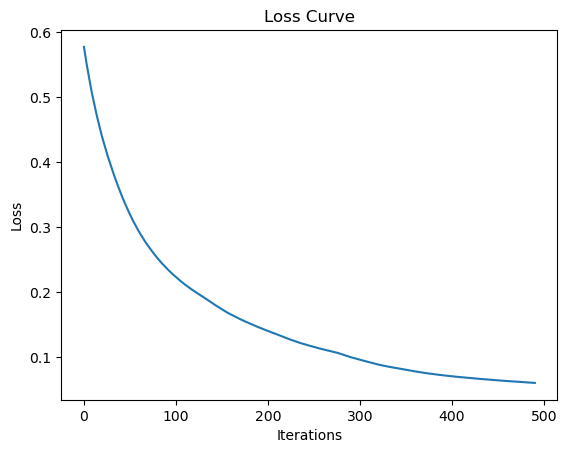

In [9]:
import seaborn as sns

sns.lineplot(x=range(len(model.loss_curve_)), y=model.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()